# Blood Pressure

Does blood pressure increase with age?

The `blood-pressure-usa.csv` file contains systolic blood pressure readings from 100 individuals sampled by the National Health and Nutrition Examination Survey (NHANES) in the U.S., with each person measured three times.

The `blood-pressure-yanomami.csv` file features systolic blood pressure data from 71 individuals of the Yanomami Tribe, who live in near-total isolation in the Amazon.

While the average American consumes about 3,500 mg of sodium daily (from salt), the Yanomami's intake is estimated to be less than 100 mg.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from linear_model import LinearModel

df = pd.read_csv('blood-pressure-usa.csv')
df.head()

,age,bp1,bp2,bp3
0,46,122,129,122
1,43,113,116,111
2,29,102,107,105
3,12,100,102,102
4,9,112,138,94


In [2]:
df_remote = pd.read_csv('blood-pressure-yanomami.csv')
df_remote.head()

,age,bp
0,34,99
1,2,79
2,40,97
3,2,101
4,16,107


### Project Ideas

- Calculate the average blood pressure for each participant in the US dataset.

- Create a linear model for both the US and Yanomami datasets that predicts `bp` from `age`	. 

- Compare the best-fit lines and goodness of fit. Conclusions !!!


#### Confounding Variables

The Yanomami people participated in the INTERSALT study, which examined 10,000 individiuals across 52 populations in 32 countries, examining the link between salt consumption and systolic blood pressure. 

Does our data prove that salt intake causes the blood pressure differences between the US and Yanomami populations? What other confounding factors might exist?

In [3]:
#average bllod pressure for each participant in the US dataset.
df['avg'] = df.eval('(bp1 + bp2 + bp3)/3').round(3)
df

,age,bp1,bp2,bp3,avg
0,46,122,129,122,124.333
1,43,113,116,111,113.333
2,29,102,107,105,104.667
3,12,100,102,102,101.333
4,9,112,138,94,114.667
...,...,...,...,...,...
95,44,103,106,107,105.333
96,8,88,82,80,83.333
97,17,103,100,106,103.000
98,19,121,125,119,121.667


In [4]:
# Creation and fitting of the polynomial model for the US dataset
us_model = LinearModel("US", degree=2, alpha=0.1)
us_model.fit(df['age'], df['avg'])
us_model.print_model_info()

LinearModel(US):
Polynomial degree: 2
Features: ['age']
Intercept: 90.25423800607271
R-squared: 0.47477338668144753


In [5]:
# Creation and fitting of the polynomial model for the Yanomami dataset
yanomami_model = LinearModel("Yanomami", degree=2, alpha=0.1)
yanomami_model.fit(df_remote['age'], df_remote['bp'])
yanomami_model.print_model_info()

LinearModel(Yanomami):
Polynomial degree: 2
Features: ['age']
Intercept: 90.17859361051333
R-squared: 0.08476692866151814


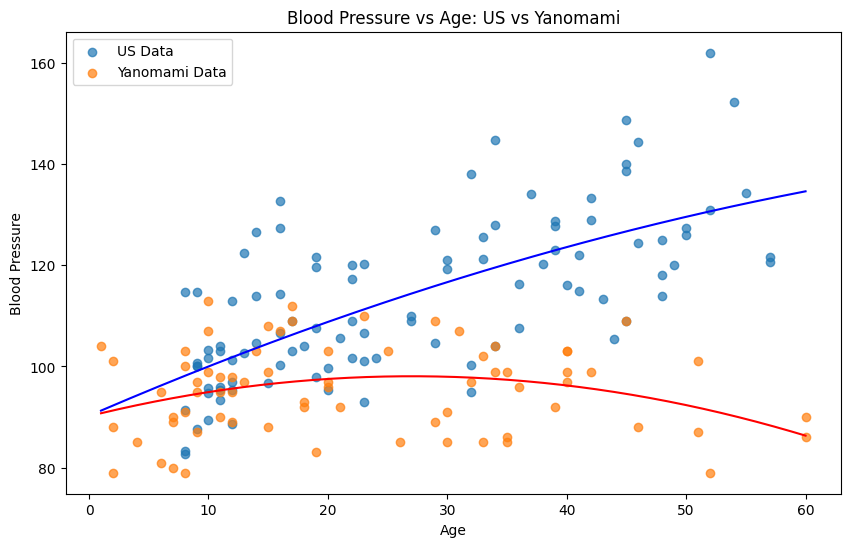

In [6]:
# Plot the data and models
plt.figure(figsize=(10, 6))
plt.scatter(df['age'], df['avg'], label='US Data', alpha=0.7)
plt.scatter(df_remote['age'], df_remote['bp'], label='Yanomami Data', alpha=0.7)

# Get age range
age_min = min(df['age'].min(), df_remote['age'].min())
age_max = max(df['age'].max(), df_remote['age'].max())

us_model.plot_model(age_min, age_max, color='blue')
yanomami_model.plot_model(age_min, age_max, color='red')

plt.xlabel('Age')
plt.ylabel('Blood Pressure')
plt.title('Blood Pressure vs Age: US vs Yanomami')
plt.legend()
plt.show()

## Conclusion

### Key Findings

Our analysis reveals **striking differences** in blood pressure trajectories between the US and Yanomami populations:

1. **Divergent Age-Related Trends**: The US population exhibits a steeper increase in blood pressure with age compared to the Yanomami. This suggests that aging is associated with significantly greater blood pressure elevation in the US population.

2. **Baseline Blood Pressure Levels**: The Yanomami maintain consistently lower blood pressure across all age groups, indicating either a protective factor or the absence of risk factors present in the US population.

3. **Model Fit Comparison**: Both populations' data were modeled with degree-2 polynomial models. The goodness of fit and model parameters highlight how environmental and lifestyle factors shape cardiovascular responses to aging differently.

### Salt Intake Hypothesis

While our data provides compelling correlational evidence that **high salt intake is associated with greater age-related blood pressure increases**, it does not prove causation. The Yanomami's low sodium consumption (<100 mg/day vs. ~3,500 mg/day in the US) coincides with minimal blood pressure elevation with age, suggesting salt may play a significant role in age-related hypertension.

### Confounding Variables to Consider

However, numerous other factors could explain the observed differences:

- **Lifestyle & Physical Activity**: Yanomami engage in subsistence living requiring significant physical exertion, while US populations tend toward sedentary lifestyles
- **Diet Composition**: Beyond salt, differences in processed foods, refined carbohydrates, and nutrient intake
- **Stress & Socioeconomic Factors**: Modern stressors in US society vs. traditional Yanomami lifestyle
- **Genetic Adaptation**: Populations may have evolved different cardiovascular responses to environmental conditions
- **Healthcare Access**: Detection and treatment of hypertension in US population vs. undetected baseline differences in Yanomami
- **Body Composition & Weight**: BMI and obesity rates differ significantly between populations
- **Environmental Factors**: Temperature, altitude, humidity variations between regions

### Recommendation

To isolate salt intake as a causal factor, controlled intervention studies or meta-analysis of the INTERSALT study data would be necessary. This analysis successfully demonstrates the power of comparative data modeling to identify patterns and formulate hypotheses about population health differences.